# This is a sample Jupyter Notebook of creating data with using LLM

In this notebook we download the data from Hugging Face. Then we generate new data using LLM.

First we load the dependencies

In [1]:
# Install dependencies as needed:
# pip install kagglehub[hf-datasets]

import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from itertools import chain
from regex import regex as re

from kagglehub import KaggleDatasetAdapter
from typing import Dict, Tuple
from datasets import load_dataset, DownloadMode
from tqdm import tqdm

from libs.llm_client import LLMClient
from libs.analyse_slang_dataset import SlangAnalyzer
# Add progress bar integration
tqdm.pandas();

C:\Users\Bjarke\PyCharmMiscProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Use the function we have defined in our libary

In [2]:
client = LLMClient()
analyser = SlangAnalyzer()
basepath = "../Data/"

In [2]:
!conda env export --no-builds > env.yml


Calling the API for each row in the Genz-slang from MLBtrio. The output would be the informal text generated from the LLM.

In [121]:
# Load the Gen Z slang dataset
dataset = load_dataset("MLBtrio/genz-slang-dataset", download_mode=DownloadMode.REUSE_CACHE_IF_EXISTS)
df_mlbtrio = pd.DataFrame(dataset['train'])
df_mlbtrio.head(5)

Generating train split: 100%|██████████| 1779/1779 [00:00<00:00, 145064.19 examples/s]


,Slang,Description,Example,Context
0,W,Shorthand for win,"Got the job today, big W!",Typically used in conversations to celebrate s...
1,L,Shorthand for loss/losing,"I forgot my wallet at home, that’s an L.",Often used when referring to a failure or mish...
2,L+ratio,Response to a comment or action on the interne...,Your tweet got 5 likes and 100 replies calling...,Popularized on social media platforms to signi...
3,Dank,excellent or of very high quality,That meme is so dank!,Commonly used in internet slang to refer to me...
4,Cheugy,Derogatory term for Millennials. Used when mil...,"That phrase is so cheugy, no one says that any...",Used to refer to things that were once popular...


In [122]:
# Analyze all three datasets
analysis_mlbtrio : Dict = analyser.analyze(
    df_mlbtrio,
    column='Slang',
    dataset_name='MLBtrio/genz-slang-dataset'
)
analyser.show_total_statistics(analysis_mlbtrio)
analyser.show_duplication_analysis(analysis_mlbtrio)


DATASET ANALYSIS: MLBtrio/genz-slang-dataset

1. Total Statistics:


,Metric,Count
0,Total Rows,"1,779"
1,Unique (Case-Sensitive),"1,605"
2,Unique (Lowercase),"1,588"


2. Duplication Analysis:


,Metric,Value
0,Duplication Rate (%),10.7%
1,Most Common Term,'gg'
2,Most Common Count,4
3,Original Cases,['GG']


## Looking into data set from Programmer-RD-AI for genz-slang
First we will load the data

In [106]:
# Load the Gen Z slang dataset
dataset_pairs = load_dataset("Programmer-RD-AI/genz-slang-pairs-1k", download_mode=DownloadMode.REUSE_CACHE_IF_EXISTS)

Generating train split: 100%|██████████| 1005/1005 [00:00<00:00, 135083.34 examples/s]


If you already have the data then load the data locally instead where there is already generated Slang columns and more. Skip to the later parts of the Notebook

In [115]:
# Load locally dataset genz-slang-pairs-1k.csv
df_pairs = pd.read_csv(basepath+ "genz-slang-pairs-1k.csv")

In [107]:
df_pairs = pd.DataFrame(dataset_pairs['train'])
#df_p.set_index(['normal', 'gen_z'], inplace=True)
#df_p.reset_index()
df_pairs.head(5)

,normal,gen_z
0,"I'm really tired today, I think I need some rest.","I'm totally drained today, need to catch some ..."
1,"I'm really tired today, I just want to relax a...","I'm hella drained today, just wanna chill at h..."
2,I'm really excited for the concert tonight.,I'm so hype for the concert tonight.
3,"I'm really tired today, I think I need some co...","I'm so drained today, I gotta get me some caff..."
4,I'm really looking forward to the weekend.,"I'm so hyped for the weekend, can't wait to tu..."


Since the data is built completely differently, whereas this exists of normal and gen z slang. We would like to produces this into the same format with the Slang, Description, Example and the generated formal and informal text form earlier.


### Extract the terms from the gen_z column
Use the LLM in the same way to create the term

In [6]:
prompt_extract = """You are a language refinement expert. You are extracting the slang term from the sentence.

Requirements:
- Provide ONLY the slang term with no explanations, quotes, or parentheses. It is only allowed to give me slang word in the sentence.
- Output only UTF-8 text characters (no emojis or special symbols)
- Do not include any meta-commentary about the task
- Do not include any meta-commentary about the word

Original text: {gen_z}

Rewritten version:"""

df_pairs = client.batch_process(
    df_pairs,
    prompt_template=prompt_extract,
    output_column="Slang"
)

In [10]:
df_pairs.head(5)

,normal,gen_z,Slang
0,"I'm really tired today, I think I need some rest.","I'm totally drained today, need to catch some ...",z's
1,"I'm really tired today, I just want to relax a...","I'm hella drained today, just wanna chill at h...",drained
2,I'm really excited for the concert tonight.,I'm so hype for the concert tonight.,hype
3,"I'm really tired today, I think I need some co...","I'm so drained today, I gotta get me some caff...",caffeine
4,I'm really looking forward to the weekend.,"I'm so hyped for the weekend, can't wait to tu...","hyped, turned up"


In [ ]:
df_pairs.to_csv("genz-slang-pairs-1k.csv", index=False)

In [116]:
# Reorder the columns and rename them so they align more with MLBtrio dataset

df_pairs = df_pairs[['Slang', 'gen_z', 'normal']].rename(columns={
    'normal': 'Informal_Text_Without_Slang',
    'gen_z': 'Example',
    'Slang': 'Slang'
})

# Save it to it own dataset
df_pairs.to_csv(basepath +"genz-slang-pairs-1k.csv", index=False)
df_pairs

,Slang,Informal_Text_Without_Slang,Example
0,z's,"I'm really tired today, I think I need some rest.","I'm totally drained today, need to catch some ..."
1,drained,"I'm really tired today, I just want to relax a...","I'm hella drained today, just wanna chill at h..."
2,hype,I'm really excited for the concert tonight.,I'm so hype for the concert tonight.
3,caffeine,"I'm really tired today, I think I need some co...","I'm so drained today, I gotta get me some caff..."
4,"hyped, turned up",I'm really looking forward to the weekend.,"I'm so hyped for the weekend, can't wait to tu..."
...,...,...,...
1000,"dip, Z's",I think I should probably get some sleep now.,"Lowkey, I gotta dip and catch some Z's soon."
1001,sick,"Hey, did you see my new phone? It's pretty cool.","Yo, did you peep my new phone? It's mad sick."
1002,sesh,"Hey, do you want to grab dinner after work?","Yo, wanna hit up a dinner sesh after work?"
1003,hit,"Hey, do you want to go grab some coffee after ...","Yo, wanna hit up coffee after work? ✨"


As we can see in the Slang index 4 or 1000, there is multiple words in each the same column just spilt by a comma. So we want to create a new list of every term, so that we can analyse how many different terms there is in the dataset.

In [123]:
# Split each row when a comma comes and have a new list
def split_by_comma(line):
    """Split line by comma, remove parentheses content, and clean up"""
    if pd.isna(line):
        return []

    line = str(line)
    # Remove content within parentheses (including the parentheses)
    line = re.sub(r'\([^)]*\)', '', line)

    # Split by comma
    terms = line.split(',')

    # Clean up each term: strip whitespace, remove quotes, and convert to lowercase
    cleaned_terms = []
    for term in terms:
        term = term.strip()
        # Remove surrounding quotes (both single and double)
        term = term.strip('"\'')
        term = term.lower()
        if term:
            cleaned_terms.append(term)

    return cleaned_terms


Now we apply the funciton and we get a list of word that exist in the

In [15]:
slang_lists = df_pairs.Slang.apply(split_by_comma)

# Set into dataframe to be able to analyse the data
df_slang_set = pd.DataFrame(slang_lists)

analysis_pairs : Dict = analyser.analyze(
    df_slang_set,
    column='Slang',
    dataset_name='Programmer-RD-AI/genz-slang-pairs-1k'
)
analyser.show_total_statistics(analysis_pairs)
analyser.show_duplication_analysis(analysis_pairs)

Total unique slang terms: 211

Slang terms:
['about', 'all arvo', 'all set', 'all-nighter', 'arvo', 'beat', 'binge', 'binge-watching', 'binged', 'bingin', 'binging', 'blazing', 'bloque', 'bopped', 'bored', 'bossed', 'bounce', 'bouncin', 'bouncing', 'brews', 'bruh', 'busted', 'buzzin', 'caffeine', 'cantbother', 'cap', 'caught', "caught  z's", 'checkin', 'chill', 'chillax', 'chilled', 'chillin', 'chilling', 'clicked', 'coffee', 'cool', 'cop', 'copped', 'cram', 'crank', 'crashed', 'crew', 'crib', 'dash', 'dashed', 'dead', 'deadass', 'deadtired grindin', 'deets', 'dip', 'dipped', 'dipping', 'dive', 'dope', 'dopest', 'down', 'drained', 'drip', 'dropped', 'dying', 'evished', 'excited', 'exhausted', 'exhuasted', 'fam', 'faves', 'fin', 'finna', 'fire', 'flex', 'flick', 'flicks', 'fr', 'fresh', 'fucc', 'ghost', 'ghosting', 'gon', 'gonna', 'gotta', 'gotta friends grub', 'grind', 'grindin', 'grinding', 'ground', 'grub', 'guiding', 'heckin', 'hectic', 'hella', 'hilarious', 'hit', 'hits', 'hitting'

## Looking into data set from Tawfia Yeasmin at Kaggle called Gen Z words and Phrases Dataset


In [127]:
# Set the path to the file you'd like to load
file_path = "gen_zz_words.csv"

# Load the latest version
hf_dataset = kagglehub.dataset_load(
  KaggleDatasetAdapter.HUGGING_FACE,
  "tawfiayeasmin/gen-z-words-and-phrases-dataset",
  file_path,
)

df_kaggle = pd.DataFrame(hf_dataset)
df_kaggle.head(5)
df_kaggle.to_csv(basepath + "gen_zz_words.csv", index=False)

In [124]:
analysis_kaggle : Dict = analyser.analyze(
    df_kaggle,
    column='Word/Phrase',
    dataset_name='Gen Z Words and Phrases Dataset'
)
analyser.show_total_statistics(analysis_kaggle)
analyser.show_duplication_analysis(analysis_kaggle)


DATASET ANALYSIS: Gen Z Words and Phrases Dataset

1. Total Statistics:


,Metric,Count
0,Total Rows,204
1,Unique (Case-Sensitive),90
2,Unique (Lowercase),89


2. Duplication Analysis:


,Metric,Value
0,Duplication Rate (%),56.4%
1,Most Common Term,'drip'
2,Most Common Count,5
3,Original Cases,['Drip']


# Comparison of how many slang term in each of the data set is duplicated

Total unique slang terms in slang_kaggle: 89
SLANG DICTIONARY COMPARISON - THREE DATASETS

Dataset Sizes:
  MLBtrio/genz-slang-dataset: 1,588 unique terms
  Programmer-RD-AI/genz-slang-pairs-1k: 211 unique terms
  Gen Z Words and Phrases Dataset: 89 unique terms

Pairwise Overlaps:
  MLBtrio vs Pairs: 18 shared (1.13% of MLBtrio)
  MLBtrio vs Kaggle: 43 shared (2.71% of MLBtrio)
  Pairs vs Kaggle: 23 shared (10.90% of Pairs)

Triple Intersection (in all three): 11 terms

Unique Terms (only in one dataset):
  Only in MLBtrio: 1,570
  Only in Pairs: 193
  Only in Kaggle: 66


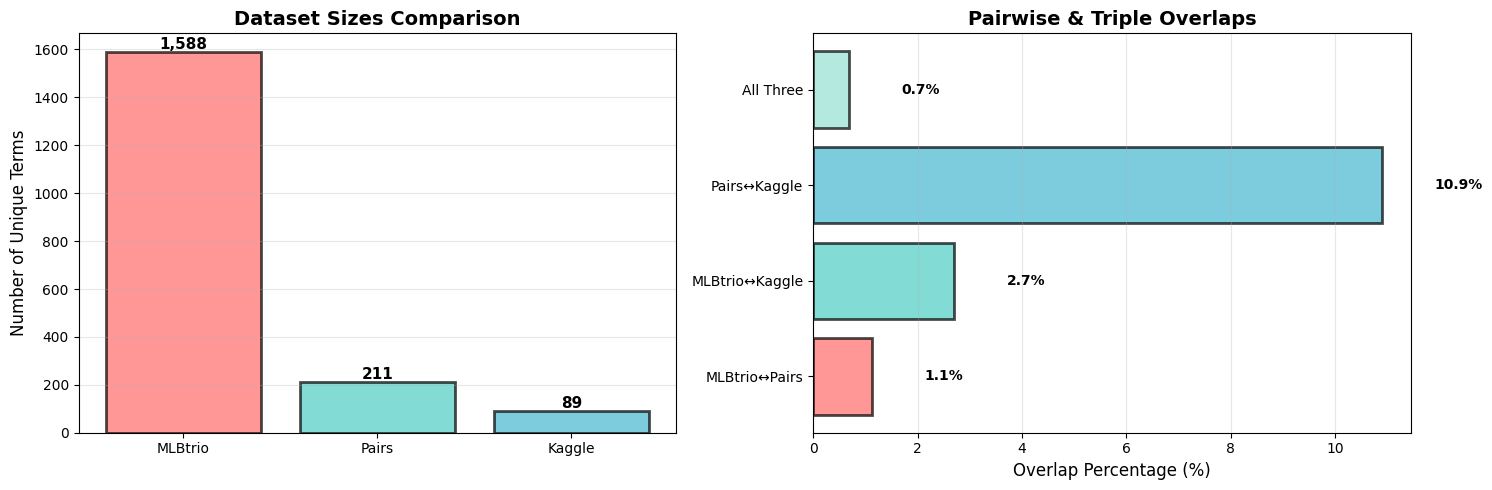

In [126]:
# --- Create sets of slang terms (normalized) ---
slang_mlbtrio = set(df_mlbtrio.Slang.str.lower())
slang_pair = set(chain.from_iterable(slang_lists))
slang_kaggle  = set(df_kaggle["Word/Phrase"].str.lower())
print(f"Total unique slang terms in slang_kaggle: {len(slang_kaggle)}")
# --- Compute pairwise intersections and differences ---

# Pair 1: MLBtrio vs Pairs
intersection_1_2 = slang_mlbtrio.intersection(slang_pair)
only_in_mlbtrio = slang_mlbtrio - slang_pair
only_in_pairs = slang_pair - slang_mlbtrio

# Pair 2: MLBtrio vs Kaggle
intersection_1_3 = slang_mlbtrio.intersection(slang_kaggle)
only_in_kaggle_vs_mlbtrio = slang_kaggle - slang_mlbtrio

# Pair 3: Pairs vs Kaggle
intersection_2_3 = slang_pair.intersection(slang_kaggle)
only_in_kaggle_vs_pairs = slang_kaggle - slang_pair

# Triple intersection (all three)
intersection_all = slang_mlbtrio.intersection(slang_pair).intersection(slang_kaggle)

# --- Print comprehensive summary ---
print("=" * 70)
print("SLANG DICTIONARY COMPARISON - THREE DATASETS")
print("=" * 70)

print(f"\nDataset Sizes:")
print(f"  MLBtrio/genz-slang-dataset: {len(slang_mlbtrio):,} unique terms")
print(f"  Programmer-RD-AI/genz-slang-pairs-1k: {len(slang_pair):,} unique terms")
print(f"  Gen Z Words and Phrases Dataset: {len(slang_kaggle):,} unique terms")

print(f"\nPairwise Overlaps:")
print(f"  MLBtrio vs Pairs: {len(intersection_1_2)} shared ({len(intersection_1_2) / len(slang_mlbtrio) * 100:.2f}% of MLBtrio)")
print(f"  MLBtrio vs Kaggle: {len(intersection_1_3)} shared ({len(intersection_1_3) / len(slang_mlbtrio) * 100:.2f}% of MLBtrio)")
print(f"  Pairs vs Kaggle: {len(intersection_2_3)} shared ({len(intersection_2_3)/len(slang_pair)*100:.2f}% of Pairs)")

print(f"\nTriple Intersection (in all three): {len(intersection_all)} terms")

print(f"\nUnique Terms (only in one dataset):")
print(f"  Only in MLBtrio: {len(only_in_mlbtrio):,}")
print(f"  Only in Pairs: {len(only_in_pairs):,}")
print(f"  Only in Kaggle: {len(only_in_kaggle_vs_pairs):,}")

# --- Visualizations ---

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Chart 1: Dataset sizes
ax1 = axes[0]
dataset_names = ['MLBtrio', 'Pairs', 'Kaggle']
dataset_sizes = [len(slang_mlbtrio), len(slang_pair), len(slang_kaggle)]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = ax1.bar(dataset_names, dataset_sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Number of Unique Terms', fontsize=12)
ax1.set_title('Dataset Sizes Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for bar, size in zip(bars, dataset_sizes):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{int(size):,}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Chart 2: Overlap percentages
ax2 = axes[1]
overlap_labels = ['MLBtrio↔Pairs', 'MLBtrio↔Kaggle', 'Pairs↔Kaggle', 'All Three']
overlap_percentages = [
    len(intersection_1_2) / max(len(slang_mlbtrio), len(slang_pair)) * 100,
    len(intersection_1_3) / max(len(slang_mlbtrio), len(slang_kaggle)) * 100,
    len(intersection_2_3) / max(len(slang_pair), len(slang_kaggle)) * 100,
    len(intersection_all) / max(len(slang_mlbtrio), len(slang_pair), len(slang_kaggle)) * 100
]

ax2.barh(overlap_labels, overlap_percentages,
         color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3'],
         alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_xlabel('Overlap Percentage (%)', fontsize=12)
ax2.set_title('Pairwise & Triple Overlaps', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for i, v in enumerate(overlap_percentages):
    ax2.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('three_dataset_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Since it is only 18 slang terms that is overlapping, there is a reason for merging these dataset. However, first we have to align the dataset, such as both of them will contain the same columns; Slang, Description, Example, Context. The Programmer-RD-AI/genz-slang-pairs-1k contains the Example and the normalized text, and we have created the terms from the text by using a LLM to detect the term. However now we have the term, but we have multiple example of the same term and in some examples there is multiple slang terms.

# This section is about aligning the data, so that they have the same fields

## ALigning MLBrio
In this section we want to make use MLBtrio dataset has the Informal_Text fields as there is in the Pairs dataset

#### Add informal text that does contain slang words
Then we create a prompt for telling the LLM what to do with the data.
Rewrite normal English text so the purpose aligns with the original slang meaning. This ensures the refined text captures the same sentiment/intent as the slang.

In [ ]:
prompt_informal_with_slang = """You are a language refinement expert. Rewrite the following text to preserve the original intent and sentiment of the slang term '{Slang}' (meaning: {Description}).

Requirements:
- Use informal, conversational English
- Capture the same emotional tone and purpose as the original slang
- Output only UTF-8 text characters (no emojis or special symbols)
- Provide ONLY the rewritten sentence with no explanations, quotes, or parentheses
- Do not include any meta-commentary about the task

Original text: {Example}

Rewritten version:"""

df_mlbtrio = client.batch_process(
    df_mlbtrio,
    prompt_template=prompt_informal_with_slang,
    output_column="Informal_Text"
)
df_mlbtrio.Informal_Text

See the new column created in the dataset

In [ ]:
df_mlbtrio.head(5)

Save the dataset to a file

In [ ]:
df_mlbtrio.to_csv("genz_slang.csv", index=False)

#### Add informal text that does not contain slang words


In [ ]:
prompt_informal   = """You are a language refinement expert. Rewrite the following text to preserve the original intent and sentiment of the slang term '{Slang}' (meaning: {Description}).

Requirements:
- Use informal, conversational English without slang
- Capture the same emotional tone and purpose as the original slang
- Output only UTF-8 text characters (no emojis or special symbols)
- Provide ONLY the rewritten sentence with no explanations, quotes, or parentheses
- Do not include any meta-commentary about the task

Original text: {Example}

Rewritten version:"""

df_mlbtrio = client.batch_process(
    df_mlbtrio.head(5),
    prompt_template=prompt_informal,
    output_column="Informal_Text_Without_Slang"
)
df_mlbtrio.Informal_Text_Without_Slang

In [ ]:
df_mlbtrio.head(5)

In [ ]:
df_mlbtrio.to_csv("genz_slang.csv", index=False)

#### Add formal text

In [ ]:
prompt = """You are a language refinement expert. Rewrite the following text to preserve the original intent and sentiment of the slang term '{Slang}' (meaning: {Description}).

Requirements:
- Use formal, conversational English without slang
- Capture the same emotional tone and purpose as the original slang
- Output only UTF-8 text characters (no emojis or special symbols)
- Provide ONLY the rewritten sentence with no explanations, quotes, or parentheses
- Do not include any meta-commentary about the task

Original text: {Example}

Rewritten version:"""

df_mlbtrio = client.batch_process(
    df_mlbtrio,
    prompt_template=prompt_formal,
    output_column="Formal_Text"
)
df_mlbtrio.Formal_Text

In [ ]:
df_mlbtrio.head(5)

In [ ]:
df_mlbtrio.to_csv("genz_slang.csv", index=False)